# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [1]:
# Package requirements
# ! pip install --upgrade pip
# ! pip install emoji pandas nltk gensim numpy tensorflow matplotlib scikit-learn
# ! pip install torch torchvision torchaudio
# ! pip install transformers datasets bitsandbytes accelerate 

In [11]:
# Standard library
import os
import re
import json
from collections import Counter, defaultdict
import gc
import random

# Third-party libraries
import numpy as np
import pandas as pd
import emoji
import gensim
import gensim.downloader as gloader
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from datasets import Dataset 
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,TrainingArguments, Trainer, set_seed
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix 
# import tensorflow as tf
# from tensorflow.keras.preprocessing.text import Tokenizer
# import evaluate

# Typing
from typing import List, Dict, Tuple, Set

DEBUG = True
if DEBUG:
    import torch
    print(torch.__version__)
    print(torch.version.cuda)

2.9.0+cu126
12.6


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [200]:
# Load and encode the jsons
train_df = pd.DataFrame(json.load(open('./A1/data/training.json'))).transpose()
test_df = pd.DataFrame(json.load(open('./A1/data/test.json'))).transpose()
val_df = pd.DataFrame(json.load(open('./A1/data/validation.json'))).transpose()
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist


train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [201]:
# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # usese recommended NLTK tokenizer
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

# NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
def clean_text_and_tokenize_lemmatize(text, patterns):
    
    # 1) Remove emojis
    # NOTE: we asked the tutors and they said that it is meant to remove only visible emojis, not text-based ones. We used the emoji library for completeness.
    # NOTE: the tutor said that we could delete or replace with text, since there are already text emoji we can't handle it could be interesting to replace them with text in order to cover them properly. On the other hand text emoji are rare in the dataset and are for sure used in a different way.
    # NOTE; we don't include the regex for emojis here since we are using the emoji library and it is more efficient and complete.
    text = emoji.replace_emoji(text, replace=' ')    
    
    # Remove other patterns
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text)

# NOTE: version that only cleans the text without tokenizing and lemmatizing (used in roberta)
def only_clean_text(text, patterns):
    # Remove emojis
    text = emoji.replace_emoji(text, replace=' ')    
    # Remove other patterns
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return text

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [202]:
# NOTE: 1 big regex for all patterns would be more efficient, but here we prefer to keep them separate for clarity

patterns = [
    
    # 2) Hashtags
    re.compile(r'#\w+'),
    
    # 3) Mentions
    re.compile(r'@\w+'),
    
    # 4) URLs
    re.compile(r'https?://[^\s]+'), 
    
    # 6) Specific quotes characters, i assume not the regular ones (e.g. " ' )
    # NOTE: we do this here explicitely in order not to implicitly remove them with the special characters pattern
    re.compile(r'[“”‘’«»`´]'), 
    
    # 5) Special characters and symbols
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters, considering also quotes, parentheses, punctuation, etc.
    re.compile(r'[^a-zA-Z0-9\s]'),

]

for i, df in enumerate(dfs):
    df['lemm_tweet'] = df["tweet"].apply(lambda text: clean_text_and_tokenize_lemmatize(text, patterns))
    df['cleaned_tweet'] = df["tweet"].apply(lambda text: only_clean_text(text, patterns))
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) compression of repeated punctuation
    # 3) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "lemm_tweet", "cleaned_tweet"]])

,tweet,lemm_tweet,cleaned_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...,FFS How about laying the blame on the bastard...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...,Writing a uni essay in my local pub with a cof...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...,it is 2021 not 1921 I dont appreciate that ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...,this is unacceptable Use her title as you d...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...,Making yourself a harder target basically bo...
...,...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...,Ma am if I say that you look like a whore Wo...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...,idk why y all bitches think having half your a...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...,This has been a part of an experiment with ...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...,Take me already Not yet You gotta be ready...


In [203]:
def build_word_listing(df):
    vocab = set()
    tokens_vec=[]
    for text in df["lemm_tweet"]:
        # NOTE: we use split since they were already tokenized and then jointed with spaces
        tokens = text.split(" ")
        vocab.update(tokens)
        tokens_vec.append(tokens)
    return sorted(vocab), tokens_vec

word_listing_train, train_corpus = build_word_listing(train_df)
if DEBUG:
    print(f"example train listing: {word_listing_train[:-100:10]}")
    print(f"corpus example:       {train_corpus[:-100:10]}")
word_listing_val, val_corpus = build_word_listing(val_df)
word_listing_test, test_corpus = build_word_listing(test_df)

example train listing: ['0', '10', '110', '14400', '164', '1900', '1974', '19yo', '200', '2014i', '2023', '24', '2am', '324k', '3fm', '42yrs', '4th', '56k', '62', '71', '81', '907', 'a108m31', 'abduct', 'abr', 'abt', 'acceptable', 'account', 'achilles', 'acting', 'actor', 'addict', 'adjust', 'admittedly', 'adorama', 'advert', 'aesthetic', 'affirm', 'african', 'against', 'ago', 'aiki', 'airborne', 'akali', 'albeit', 'alibi', 'all', 'allison', 'alone', 'alse', 'always', 'amazon', 'america', 'amuse', 'analysis', 'and', 'ang', 'anguish', 'annoy', 'anthem', 'anus', 'anyway', 'apni', 'appealing', 'appointment', 'approximation', 'archaeology', 'arena', 'aristocrat', 'armour', 'arrogant', 'as', 'asia', 'ass', 'assignmentsonline', 'astound', 'athena', 'attend', 'atwood', 'aul', 'authority', 'automotive', 'ave', 'aware', 'awkward', 'ayleen', 'babu', 'backward', 'badly', 'baked', 'balk', 'banter', 'barely', 'basic', 'bateman', 'bayern', 'bdsm', 'beautification', 'become', 'beep', 'behavior', 'bel

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [6]:
# Hyperparams
WINDOW_SIZE = 5
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"

In [ ]:
# FUNCTIONS

def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e


def build_alacarte_transform(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    window_size: int = 5
) -> np.ndarray:
    
    """
    Compute A-La-Carte transformation matrix from a training corpus.

    Reference:
    Khodak, M., Saunshi, N., & Liang, P. (2018).
    "A La Carte Embedding: Cheap but Effective Induction of Semantic Feature Vectors."
    ACL 2018.

    :param train_corpus: tokenized training corpus
    :param embedding_model: pre-trained embedding model
    :param window_size: size of context window for each word
    :return: transformation matrix A (embedding_dim x embedding_dim)
    """
    
    context_vectors = {}
    context_counts = {}

    # Build averaged context vectors for each word
    for sentence in train_corpus:
        for i, word in enumerate(sentence):
            
            # Skip words without a pretrained embedding as they cannot serve as regression targets
            if word not in embedding_model:
                continue 
            
            # Collect embeddings for neighboring [+window_size, -window_size], excluding the current word
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            context = [embedding_model[w] for w in sentence[start:i] + sentence[i+1:end] if w in embedding_model]
            if context:
                avg_ctx = np.mean(context, axis=0)
                if word in context_vectors:
                    context_vectors[word] += avg_ctx
                    context_counts[word] += 1
                else:
                    context_vectors[word] = avg_ctx
                    context_counts[word] = 1

    # Normalize by occurrences
    for word in context_vectors:
        context_vectors[word] /= context_counts[word]

    U = np.array([context_vectors[w] for w in context_vectors])
    V = np.array([embedding_model[w] for w in context_vectors])
    
    # Linear regression to find transformation matrix
    A = np.linalg.lstsq(U, V, rcond=None)[0].T
    return A


def build_vocabulary_train_union(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    DEBUG: bool = False
) -> Tuple[Set[str], Set[str]]:
    
    """
    Union of training tokens and embedding vocabulary.

    :return: (vocabulary union, training tokens)
    """
    
    train_tokens = set(tok for sent in train_corpus for tok in sent)
    embedding_vocab = set(embedding_model.index_to_key)
    vocabulary = train_tokens | embedding_vocab
    
    if DEBUG:
        print(f"Training tokens: {len(train_tokens)}")
        print(f"Embedding vocabulary: {len(embedding_vocab)}")
        print(f"Vocabulary union: {len(vocabulary)}")

    return vocabulary, train_tokens


def create_custom_embeddings_for_train_oov(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    transform_matrix: np.ndarray,
    DEBUG: bool = False
) -> Dict[str, np.ndarray]:
    
    """
    Generate embeddings for training OOV tokens using A-La-Carte.
    
    Reference:
    Khodak, M., Saunshi, N., & Liang, P. (2018).
    "A La Carte Embedding: Cheap but Effective Induction of Semantic Feature Vectors."
    ACL 2018.

    :return: dict mapping OOV token -> embedding vector
    """
    
    embedding_dim = embedding_model.vector_size
    train_tokens = set(tok for sent in train_corpus for tok in sent)
    train_oov = train_tokens - set(embedding_model.index_to_key)

    if DEBUG:
        print(f"Training OOV tokens ({len(train_oov)}): {list(train_oov)[:20]} ...")
        print(f"oov_training percentage = {len(train_oov) * 100 / len(train_tokens):.2f}%")

    # Collect contexts for OOV tokens
    oov_contexts = defaultdict(list)
    for sentence in train_corpus:
        for word in sentence:
            if word in train_oov:
                context = [w for w in sentence if w != word and w in embedding_model]
                if context:
                    oov_contexts[word].append(context)

    # Compute the embedding based on OOV contexts, if any
    custom_embeddings = {}
    for word in train_oov:
        if oov_contexts[word]:
            avg_vecs = [np.mean([embedding_model[w] for w in ctx], axis=0) for ctx in oov_contexts[word]]
            final_context = np.mean(avg_vecs, axis=0)
            custom_embeddings[word] = transform_matrix @ final_context
        else:
            custom_embeddings[word] = np.random.normal(0, 0.1, embedding_dim)

    return custom_embeddings


def build_tokenizer_with_vocabulary(
    vocabulary: Set[str],
    train_tokens: Set[str],
    oov_token: str = "<OOV>"
) -> Tokenizer:
    
    """
    Build a Keras tokenizer from a fixed vocabulary.
    Fits on train_tokens first, then statically adds remaining vocabulary tokens.
    
    :param vocabulary: Complete vocabulary (train + embedding tokens)
    :param train_tokens: Tokens from training corpus only
    :param oov_token: Token to use for out-of-vocabulary words
    :return: Configured tokenizer with full vocabulary
    """
    
    tokenizer = Tokenizer(oov_token=oov_token)
    
    # Dynamic tokenization: fit on training tokens
    # NOTE: This automatically adds OOV token at index 1 and reserves index 0 for padding
    tokenizer.fit_on_texts([' '.join(train_tokens)]) 
    
    # Static addition: add embedding tokens not in training set
    # NOTE: We add these statically because GloVe tokens may contain special chars
    # (punctuation, URLs, etc.) that Keras tokenizer would split during fitting
    max_idx = max(tokenizer.word_index.values()) 
    for token in sorted(vocabulary - train_tokens):
        max_idx += 1
        tokenizer.word_index[token] = max_idx
    tokenizer.index_word = {idx: word for word, idx in tokenizer.word_index.items()}
    tokenizer.document_count = len(vocabulary)
    
    return tokenizer


def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    train_custom_embeddings: Dict[str, np.ndarray],
    oov_token: str = "<OOV>",
    verbose: bool = False,
    debug_dict: dict = None
) -> np.ndarray:
    """
    Construct embedding matrix for Keras model: pre-trained + custom embeddings.

    :return: embedding matrix (vocab_size x embedding_dim)
    """
    embedding_dim = embedding_model.vector_size
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    glove_count = 0
    custom_count = 0
    others_count = 0

    for word, idx in tokenizer.word_index.items():
        if word == oov_token:
            # OOV token gets a small random vector
            # NOTE: it will be updated at inference time by considering the context in the test/val batch
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            if verbose : print(f"[OOV]       idx={idx} -> random vector")
            if debug_dict is not None: debug_dict["OOV"]=word

        elif word in embedding_model:
            # Pre-trained embedding exists 
            embedding_matrix[idx] = embedding_model[word]
            glove_count += 1  
            if verbose : print(f"[PRE-TRAIN] idx={idx} '{word}' -> pre-trained embedding")
            if debug_dict is not None: debug_dict["PRE-TRAIN"]=word

        elif word in train_custom_embeddings:
            # Custom embedding available
            embedding_matrix[idx] = train_custom_embeddings[word]
            custom_count += 1 
            if verbose : print(f"[CUSTOM]    idx={idx} '{word}' -> custom embedding")
            if debug_dict is not None: debug_dict["CUSTOM"]=word

        else:
            # Word not found in any embedding source, assign random vector
            # NOTE: this shouldn't happen
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            others_count += 1
            if verbose : print(f"[ELSE]      idx={idx} '{word}' -> no embedding found, random vector")
            if debug_dict is not None: debug_dict["ELSE"]=word

    if verbose:
        print(f"Embedding matrix built: {glove_count} pre-trained, {custom_count} custom, {others_count} others")
        
    return embedding_matrix

In [ ]:
# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

# Build A-La-Carte transformation matrix
A = build_alacarte_transform(train_corpus, embedding_model, window_size=WINDOW_SIZE)

# Create vocabulary union
vocabulary, train_tokens = build_vocabulary_train_union(train_corpus, embedding_model, DEBUG=DEBUG)

# Generate custom embeddings for training OOV tokens
train_custom_embeddings = create_custom_embeddings_for_train_oov(
    train_corpus, embedding_model, A, DEBUG=DEBUG
)

# Build tokenizer with full vocabulary
tokenizer = build_tokenizer_with_vocabulary(vocabulary, train_tokens, oov_token=OOV_TOKEN)
vocab_size = len(tokenizer.word_index) + 1 # +1 for index 0 for padding

print(f"Vocabulary size: {vocab_size}")

# Build embedding matrix
embedding_matrix = build_embedding_matrix(
    tokenizer, embedding_model, train_custom_embeddings, oov_token=OOV_TOKEN,
    verbose=False
)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

# NOTE: the test/val OOV will be handled at inference time thanks to the contexts of the batches

Training tokens: 9116
Embedding vocabulary: 400000
Vocabulary union: 400930
Training OOV tokens (930): ['lalalala', 'itseems', 'masqurading', 'straigh', 'agreementsoctober', 'patrilineage', 'heartattacksyoursickchildyourfailingkidneyscarcrashvictimsand', 'depency', 'sisterscene', 'underpantshaving', 'availiaple', 'feelbut', 'bateshive', 'tlj', 'wfwlct', 'mainexlazada', 'egirl', 'anyhoo', 'porsha', 'wgtn'] ...
oov_training percentage = 10.20%
Vocabulary size: 400932
Embedding matrix shape: (400932, 50)


## Extra: visualization of embedding

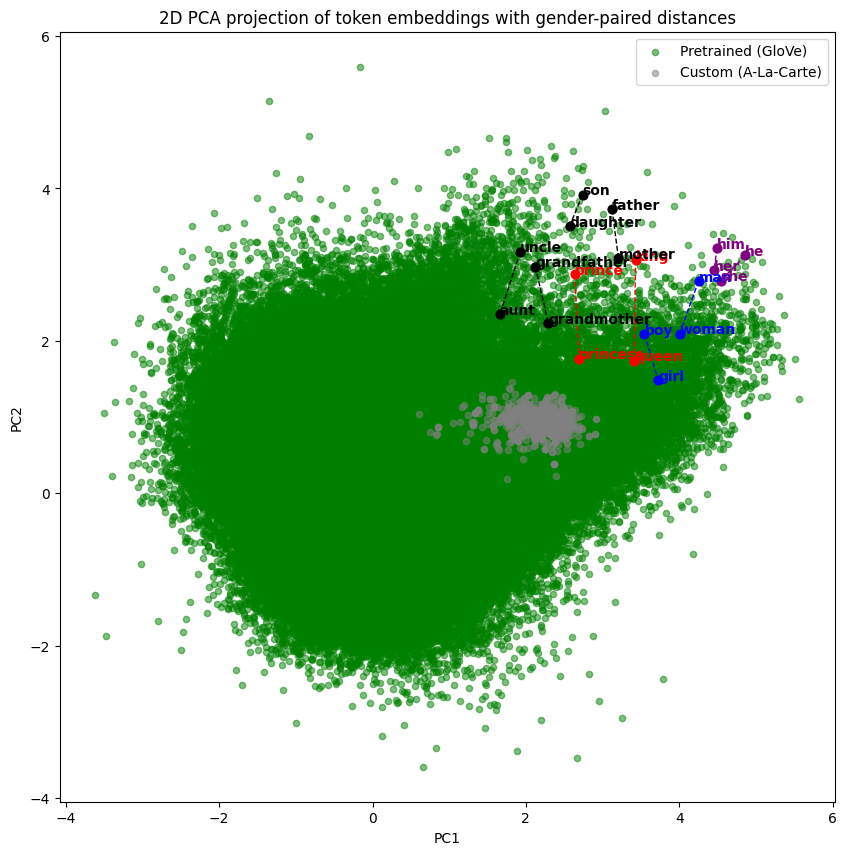

In [ ]:
token_to_embedding = {word : embedding_matrix[idx] for word, idx in tokenizer.word_index.items()}
tokens = list(token_to_embedding.keys())
embeddings = np.array([token_to_embedding[t] for t in tokens])

# NOTE: the 3d reduction wasn't more informative so we kept only this one
pca_2d = PCA(n_components=2)
embeddings_2d = pca_2d.fit_transform(embeddings)
token_to_2d = {token: embeddings_2d[i] for i, token in enumerate(tokens)}

# Separate tokens into pretrained (from GloVe) and custom (A-La-Carte generated)
pretrained_tokens = set(embedding_model.index_to_key)
custom_tokens = set(train_custom_embeddings.keys())

# Get embeddings for each category
pretrained_coords = np.array([token_to_2d[t] for t in tokens if t in pretrained_tokens])
custom_coords = np.array([token_to_2d[t] for t in tokens if t in custom_tokens])

# Define gender-paired tuples
# TODO: add more and more informative
gender_pairs = (
    (("king", "queen"), ("prince", "princess")),
    (("man", "woman"), ("boy", "girl")),
    (("father", "mother"), ("son", "daughter"), ("grandfather", "grandmother"), ("uncle", "aunt")),
    (("he", "she"), ("him", "her")),
)
word_groups = [(
    word 
    for pair in group 
    for word in pair 
) for group in gender_pairs]

# Define up to 10 distinct colors for the groups 
group_colors = [ 
    "red", "blue", "black", "purple", "orange",
    "pink", "cyan", "magenta", "black", "yellow",
    "brown" 
]

plt.figure(figsize=tuple(np.array((10,10)) * 1)) # NOTE: to easysily scale the plot

# Plot pretrained tokens in green and custom tokens in gray
plt.scatter(pretrained_coords[:, 0], pretrained_coords[:, 1], alpha=0.5, color="green", label="Pretrained (GloVe)", s=20)
plt.scatter(custom_coords[:, 0], custom_coords[:, 1], alpha=0.5, color="grey", label="Custom (A-La-Carte)", s=20)

# Plot each group with color
for i, group in enumerate(word_groups):
    color = group_colors[i % len(group_colors)]
    for w in group:
        if w in token_to_2d:
            c = token_to_2d[w]
            plt.scatter(c[0], c[1], color=color, s=40) 
            plt.text(c[0], c[1], w, fontsize=10, color=color, weight='bold')

# Draw lines between gender-paired words
for i, pair_group in enumerate(gender_pairs):
    color = group_colors[i % len(group_colors)]
    for w1, w2 in pair_group:
        if w1 in token_to_2d and w2 in token_to_2d:
            c1, c2 = token_to_2d[w1], token_to_2d[w2]
            plt.plot([c1[0], c2[0]], [c1[1], c2[1]], color=color, linestyle='--', linewidth=1)

plt.title("2D PCA projection of token embeddings with gender-paired distances")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [ ]:
# embedding = tf.keras.layers.Embedding(input_dim=vocab_size,
#                                       output_dim=embedding_dimension,
#                                       weights=[embedding_matrix],
#                                       mask_zero=True,                   # automatically masks padding tokens
#                                       name='encoder_embedding')

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

In [204]:
TASK='hate'
MODEL_CARD = f"twitter-roberta-base-{TASK}"
NUM_LABLES = 4
output_dir = "./pt_checkpoints"
seeds = [42, 26, 6]

# Dataset preparation

# TODO: tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_text_precleaned(tweets):
    return tokenizer(tweets['cleaned_tweet'], truncation=True, padding=True , return_tensors="pt")

train_data = Dataset.from_pandas(train_df[["cleaned_tweet","label"]])
test_data = Dataset.from_pandas(test_df[["cleaned_tweet","label"]])
val_data = Dataset.from_pandas(val_df[["cleaned_tweet","label"]])
train_data = train_data.map(preprocess_text_precleaned, batched=True)
test_data = test_data.map(preprocess_text_precleaned, batched=True)
val_data = val_data.map(preprocess_text_precleaned, batched=True)

Map: 100%|████████████████████| 150/150 [00:00<00:00, 16089.03 examples/s]


In [205]:
# TASK='hate'
# MODEL_CARD = f"twitter-roberta-base-{TASK}"
# NUM_LABLES = 4
# output_dir = "./pt_checkpoints"
# seeds = [42, 26, 6]

# # Dataset preparation
# train_df = train_df[["cleaned_tweet","label"]]
# test_df = test_df[["cleaned_tweet","label"]]
# val_df = val_df[["cleaned_tweet","label"]]

# train_data = Dataset.from_pandas(train_df)
# test_data = Dataset.from_pandas(test_df)
# val_data = Dataset.from_pandas(val_df)

# # TODO: tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD)
# tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD, use_fast=True)
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# def preprocess_text(tweets):
#     return tokenizer(tweets['cleaned_tweet'], truncation=True, padding=True , return_tensors="pt")
# train_data = train_data.map(preprocess_text, batched=True)
# test_data = test_data.map(preprocess_text, batched=True)
# val_data = val_data.map(preprocess_text, batched=True)


In [206]:
# check the datasets
if DEBUG:
    print(train_data)
    print(test_data)
    print(val_data)
    print("Encoding of labels:")
    print(" \"-\":0, \"DIRECT\":1, \"JUDGEMENTAL\":2, \"REPORTED\":3")
    print(set(train_data['label']))

    original_text = train_data['cleaned_tweet'][26]
    decoded_text = tokenizer.decode(train_data['input_ids'][26])
    print("Original vs Decoded example:")
    print(original_text[:150])
    print(decoded_text[:150])


Dataset({
    features: ['cleaned_tweet', 'label', 'input_ids', 'attention_mask'],
    num_rows: 2873
})
Dataset({
    features: ['cleaned_tweet', 'label', 'input_ids', 'attention_mask'],
    num_rows: 280
})
Dataset({
    features: ['cleaned_tweet', 'label', 'input_ids', 'attention_mask'],
    num_rows: 150
})
Encoding of labels:
 "-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3
{0, 1, 2, 3}
Original vs Decoded example:
Anita as an asset  Damn I should ve considered that  Her vs gamergate was one big spectacle  
<s>Anita as an asset  Damn I should ve considered that  Her vs gamergate was one big spectacle  </s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>


In [207]:
def compute_metrics(output_info):
    logits, labels = output_info
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy,
        "custom_metric": (f1 + accuracy) / 2
    }

def count_trainable_parameters(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def train_evaluate_model(
    seeds: list[int],
    hyperparameters: dict,
    output_dir: str = "./pt_checkpoints",
    fine_tune_partially: bool = False,
    DEBUG: bool = False,
    plot: bool = True,
    best_subdir_name: str = "best_model"  # folder name inside each run folder where best model is saved
) -> tuple[list[dict], dict, dict]:
    """
    Returns:
      - results: list[dict] with per-seed metrics (same as before)
      - logs: dict of raw trainer.log_history if DEBUG True per seed
      - best_model_dirs: dict mapping seed -> path where the seed's best model is saved
    """
    results = []
    logs = {}
    best_model_dirs = {}

    for seed in seeds:
        print(f"\n=== RUN seed={seed} ===")
        # deterministic seeds 
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        # HF helper (sets python/numpy/torch seeds)
        set_seed(seed)

        # HF helper (sets python/numpy/torch seeds)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # unique output folder per seed so things don't overwrite
        run_output_dir = os.path.join(output_dir, f"seed_{seed}")
        os.makedirs(run_output_dir, exist_ok=True)

        # Model loading
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_CARD,
            num_labels=NUM_LABLES,
            from_tf=False,
            ignore_mismatched_sizes=True,
            id2label=reverse_mapping,
            label2id=label_mapping
        )

        if plot:
            if seed == seeds[0]:
                print(model)
                trainable, total = count_trainable_parameters(model)
                print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        if fine_tune_partially:
            print("Freezing encoder parameters, fine-tuning classification head only.")
            for param in model.roberta.parameters():
                param.requires_grad = False
            for name, param in model.named_parameters():
                if "classifier" in name or "pooler" in name or "dense" in name:
                    param.requires_grad = True
            trainable, total = count_trainable_parameters(model)
            print(f"Trainable params after freezing encoder: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        # Training
        training_args = TrainingArguments(
            output_dir=run_output_dir,             
            learning_rate=hyperparameters["learning_rate"],                   
            per_device_train_batch_size=hyperparameters["batch_size"],     # defines distributed training
            per_device_eval_batch_size=hyperparameters["batch_size"],
            num_train_epochs=hyperparameters["epochs"],
            weight_decay=hyperparameters["weight_decay"],
            eval_strategy="epoch",             # when to report evaluation metrics/losses
            save_strategy="epoch",             # when to save checkpoint
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="custom_metric",   # ensure best model by macro F1
            greater_is_better=True,
            report_to='none',                   # disabling wandb 
            seed=seed
        )
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=val_data,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()

        # gather logs and optional debug storage
        logs_hist = trainer.state.log_history
        df_logs = pd.DataFrame(logs_hist)
        if DEBUG:
            logs[seed] = logs_hist
        if plot:
            plot_metrics_over_epochs(df_logs)  # your plotting helper

        # best info
        best_metric = trainer.state.best_metric
        best_epoch = None
        df_eval = df_logs[df_logs["eval_custom_metric"].notna()].copy()
        if not df_eval.empty:
            best_row = df_eval.loc[df_eval["eval_custom_metric"].idxmax()]
            if pd.notna(best_row.get("epoch", np.nan)):
                best_epoch = float(best_row["epoch"])

        # Evaluate on validation and test
        val_res = trainer.evaluate(eval_dataset=val_data)
        test_res = trainer.evaluate(eval_dataset=test_data)

        record = {
            "seed": seed,
            "val_macro_f1": val_res.get("eval_macro_f1"),
            "val_macro_precision": val_res.get("eval_macro_precision"),
            "val_macro_recall": val_res.get("eval_macro_recall"),
            "val_accuracy": val_res.get("eval_accuracy"),
            "test_macro_f1": test_res.get("eval_macro_f1"),
            "test_macro_precision": test_res.get("eval_macro_precision"),
            "test_macro_recall": test_res.get("eval_macro_recall"),
            "test_accuracy": test_res.get("eval_accuracy"),
            "best_epoch": best_epoch,
            "best_metric": best_metric,
        }
        results.append(record)
        
        if best_subdir_name is not None:
            # Save best model into a dedicated subfolder so it's easy to reload later
            best_dir = os.path.join(run_output_dir, best_subdir_name)
            os.makedirs(best_dir, exist_ok=True)

            # Trainer.save_model will save the model and config into best_dir
            trainer.save_model(best_dir)

            best_model_dirs[seed] = best_dir

        # clean up GPU memory
        del trainer
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return results, logs, best_model_dirs


# Compute mean and std (for validation and test metrics)

def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy",
        "test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run

In [208]:
def plot_metrics_over_epochs(df_logs: pd.DataFrame):
    """
    Plots:
      - Validation (and training if available) macro-F1 vs precision vs recall across epochs.
      - Loss vs Accuracy for validation and training (training accuracy may be absent).
    df_logs : DataFrame produced from `trainer.state.log_history`.
    """
    # make a safe copy
    df = df_logs.copy()

    # Ensure epoch column exists for grouping; some entries may have fractional epochs or step-level logs
    # We'll group by epoch and take the last available metric for that epoch (more representative).
    df['epoch'] = df.get('epoch', None)

    # Helper to extract series: returns dict epoch -> value
    def epoch_series(key):
        if key in df.columns:
            tmp = df[df[key].notna()].copy()
            if 'epoch' in tmp.columns:
                # take last value per epoch
                return tmp.groupby('epoch')[key].last().sort_index()
            else:
                # no epoch recorded (rare); return the whole series
                return tmp[key]
        return None

    # Validation metrics (expect eval_* keys)
    eval_f1 = epoch_series('eval_macro_f1')
    eval_prec = epoch_series('eval_macro_precision')
    eval_rec = epoch_series('eval_macro_recall')
    eval_loss = epoch_series('eval_loss')
    eval_acc = epoch_series('eval_accuracy')

    # Training metrics: HF usually logs 'loss' for training steps; some setups also log train_* metrics
    # We'll attempt to compute a train-loss-per-epoch by taking the last training 'loss' entry per epoch.
    train_loss = None
    if 'loss' in df.columns:
        tmp = df[df['loss'].notna()].copy()
        if 'epoch' in tmp.columns:
            train_loss = tmp.groupby('epoch')['loss'].last().sort_index()
        else:
            train_loss = tmp['loss']

    train_f1 = epoch_series('train_macro_f1')      # optional
    train_prec = epoch_series('train_macro_precision')
    train_rec = epoch_series('train_macro_recall')
    train_acc = epoch_series('train_accuracy')

    # Plot 1: F1 / Precision / Recall
    plt.figure(figsize=(10, 5))
    plotted_any = False

    if eval_f1 is not None:
        plt.plot(eval_f1.index, eval_f1.values, marker='o', label='val F1')
        plotted_any = True
    if eval_prec is not None:
        plt.plot(eval_prec.index, eval_prec.values, marker='o', label='val Precision')
        plotted_any = True
    if eval_rec is not None:
        plt.plot(eval_rec.index, eval_rec.values, marker='o', label='val Recall')
        plotted_any = True

    # overlay training metrics if present
    if train_f1 is not None:
        plt.plot(train_f1.index, train_f1.values, linestyle='--', marker='x', label='train F1')
    if train_prec is not None:
        plt.plot(train_prec.index, train_prec.values, linestyle='--', marker='x', label='train Precision')
    if train_rec is not None:
        plt.plot(train_rec.index, train_rec.values, linestyle='--', marker='x', label='train Recall')

    if not plotted_any:
        # nothing useful to show
        plt.text(0.5, 0.5, "No F1 / precision / recall metrics logged", ha='center', va='center')
    else:
        plt.xlabel('epoch')
        plt.ylabel('score')
        plt.title('F1 / Precision / Recall by epoch')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()

    # Plot 2: Loss vs Accuracy
    plt.figure(figsize=(10, 5))
    any_plot = False

    # prefer plotting train_loss (if available) and eval_loss
    if train_loss is not None:
        plt.plot(train_loss.index, train_loss.values, linestyle='-', marker='.', label='train loss', color='orange')
        any_plot = True
    if eval_loss is not None:
        plt.plot(eval_loss.index, eval_loss.values, linestyle='-', marker='.', label='val loss', color='red')
        any_plot = True

    # create twin axis for accuracy (same x)
    if eval_acc is not None or train_acc is not None:
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        if eval_acc is not None:
            ax2.plot(eval_acc.index, eval_acc.values, linestyle='--', marker='s', label='val accuracy', color='blue')
            any_plot = True
        if train_acc is not None:
            ax2.plot(train_acc.index, train_acc.values, linestyle='--', marker='v', label='train accuracy', color='green')
            any_plot = True
        ax1.set_ylabel('loss', color='red')
        ax2.set_ylabel('accuracy', color='blue')
        # combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    else:
        if any_plot:
            plt.legend(loc='best')

    if not any_plot:
        plt.text(0.5, 0.5, "No loss/accuracy metrics logged", ha='center', va='center')
    else:
        plt.xlabel('epoch')
        plt.title('Loss (train/val) and Accuracy')
        plt.grid(True)
    plt.tight_layout()
    plt.show()


=== RUN seed=42 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.708300,0.679574,0.492560,0.513487,0.494902,0.826667,0.659613
2,0.547100,0.600866,0.515032,0.485673,0.557712,0.800000,0.657516
3,0.388900,0.707865,0.670675,0.785473,0.631366,0.840000,0.755337
4,0.258700,0.815664,0.563539,0.641498,0.534472,0.806667,0.685103
5,0.163100,0.908778,0.544879,0.619600,0.516020,0.806667,0.675773


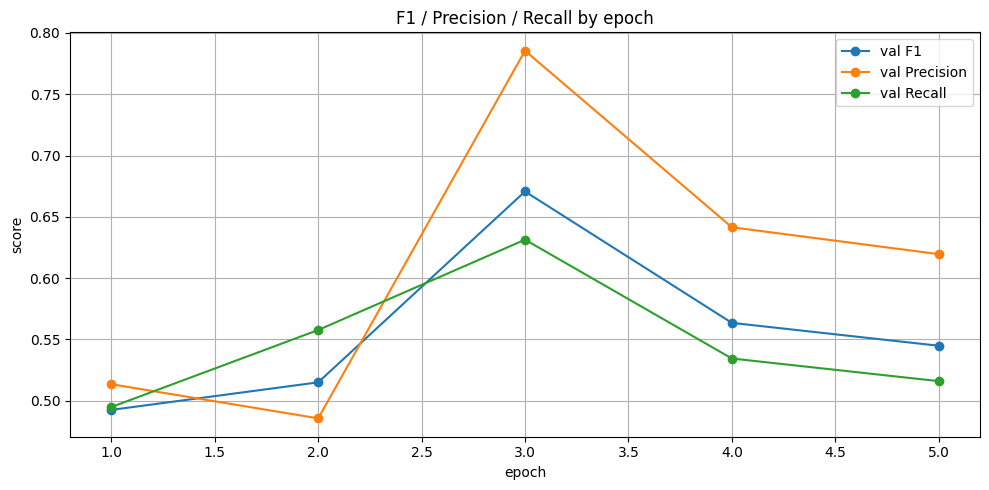

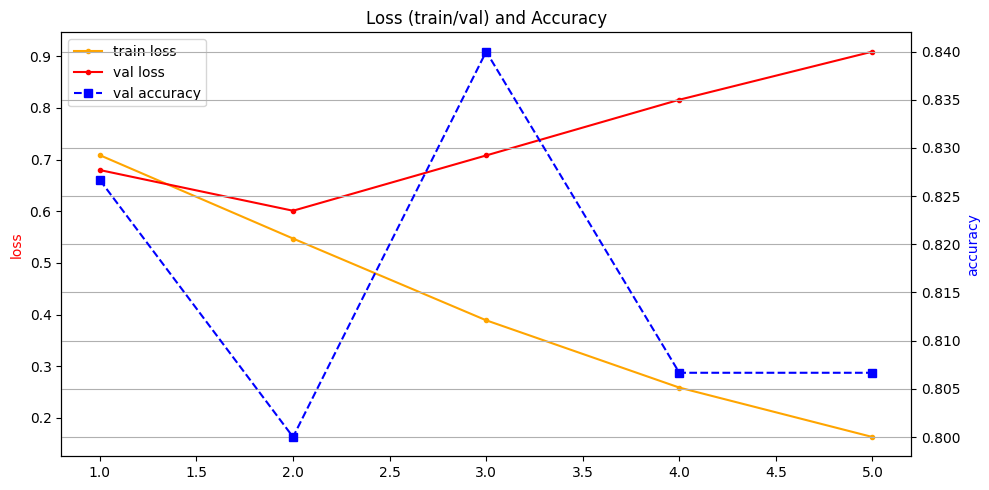


=== RUN seed=26 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.703100,0.757394,0.464349,0.622312,0.458437,0.800000,0.632174
2,0.522200,0.545836,0.588406,0.607036,0.576139,0.820000,0.704203
3,0.362300,1.070349,0.438146,0.592384,0.427614,0.773333,0.605740
4,0.242300,1.045016,0.582729,0.735417,0.529244,0.800000,0.691365
5,0.153000,1.098751,0.533333,0.706061,0.491900,0.786667,0.660000


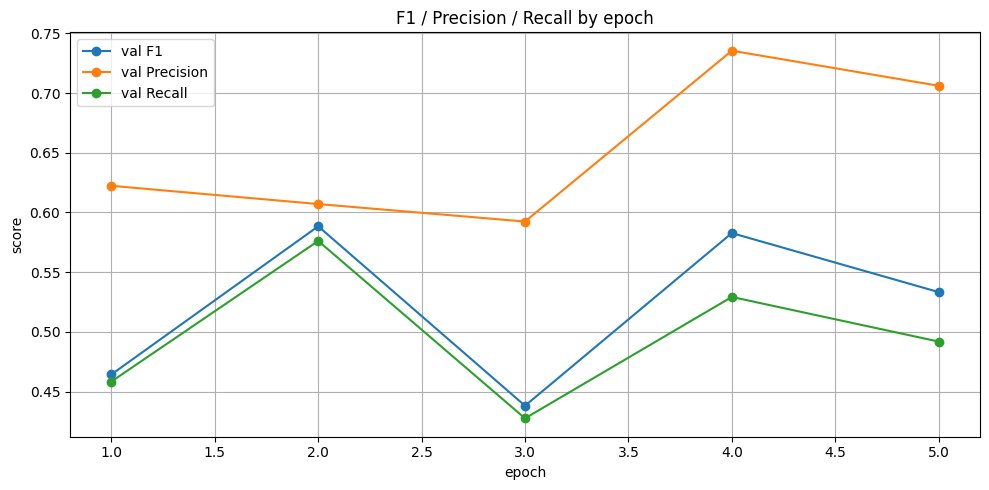

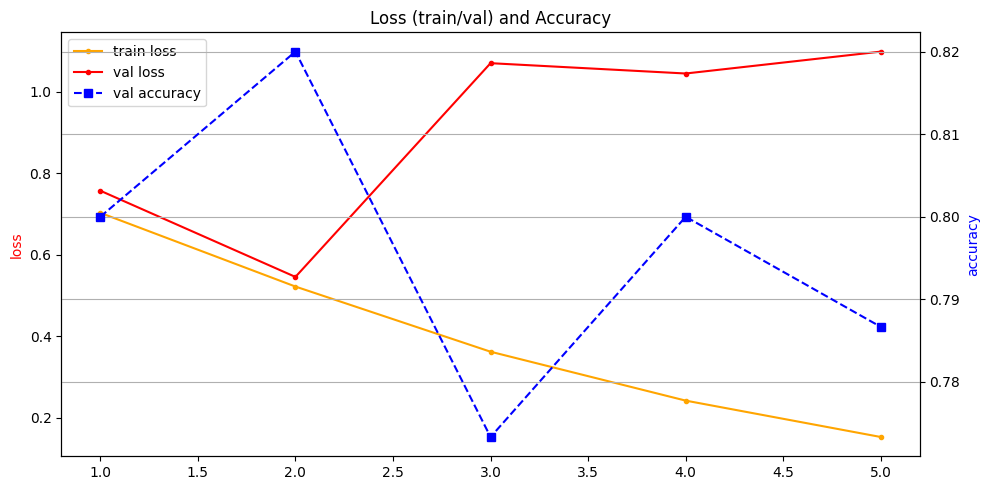


=== RUN seed=6 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.721300,0.586738,0.432401,0.607097,0.465450,0.800000,0.616200
2,0.527200,0.644807,0.530575,0.878963,0.524534,0.826667,0.678621
3,0.361900,0.783161,0.510276,0.498080,0.524664,0.806667,0.658471
4,0.219500,0.934690,0.564538,0.698598,0.526889,0.813333,0.688936
5,0.121100,0.983351,0.574291,0.669600,0.536853,0.813333,0.693812


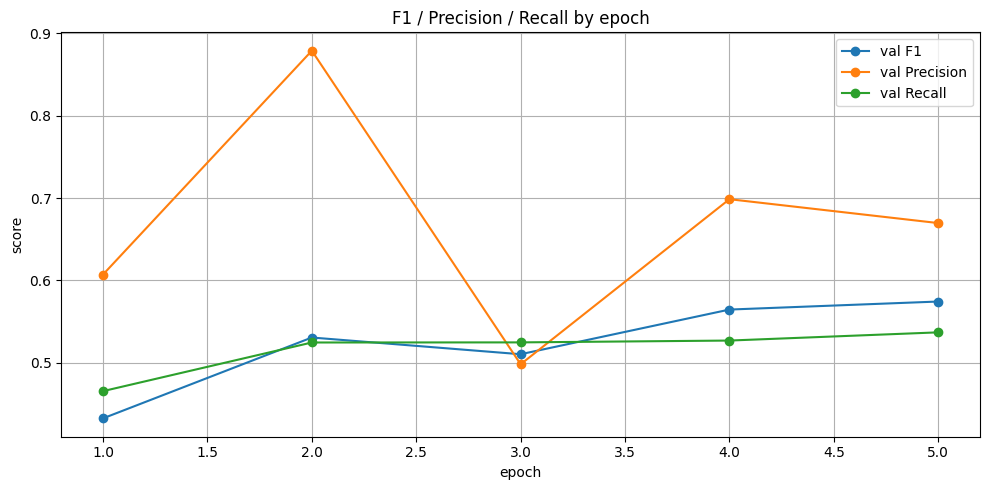

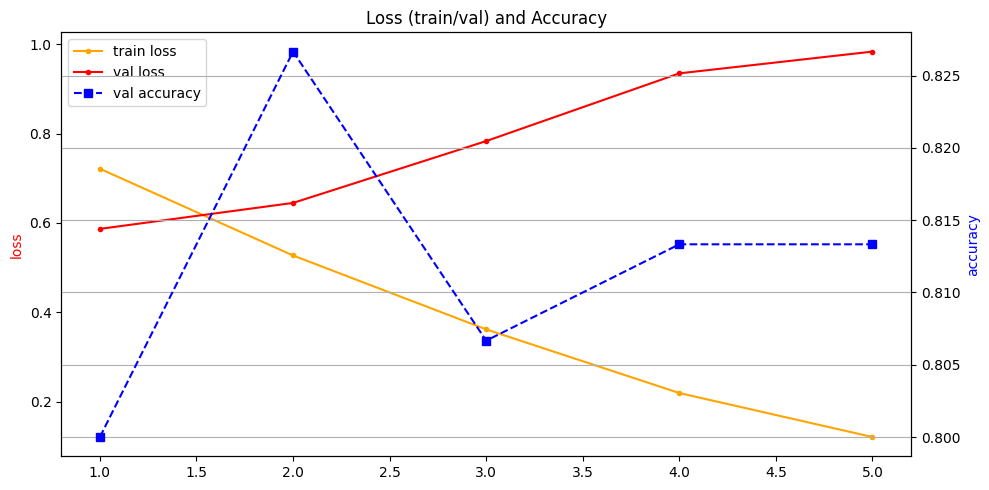

In [209]:
# Hyperparameters
hyper = {
    "batch_size": 8,
    "epochs": 5,
    "learning_rate": 3e-5,
    "weight_decay": 0.01
}

results, logs, best_model_dirs = train_evaluate_model(seeds, hyper, output_dir, fine_tune_partially = False, DEBUG=True)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

In [210]:
display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
agg, best_run = mean_std(df_out)
display(agg)
best_seed = int(best_run.to_dict()["seed"])
print("Best run seed =", best_seed)
# Reload a saved best model for seed 42:
best_dir_for_seed = best_model_dirs[best_seed]
model_seed = AutoModelForSequenceClassification.from_pretrained(best_dir_for_seed)
tokenizer = AutoTokenizer.from_pretrained(best_dir_for_seed)
model_seed.to('cuda' if torch.cuda.is_available() else 'cpu')
training_args = TrainingArguments(report_to='none')
trainer = Trainer(
    model=model_seed,
    args=training_args,
    eval_dataset=test_data,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
metrics = trainer.evaluate()
display(pd.DataFrame([metrics]))

,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
1,42,0.670675,0.785473,0.631366,0.840000,3.0
2,26,0.588406,0.607036,0.576139,0.820000,2.0
0,6,0.574291,0.669600,0.536853,0.813333,5.0


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
1,42,0.537509,0.583928,0.534062,0.746429,3.0
2,26,0.517616,0.540247,0.524834,0.721429,2.0
0,6,0.561342,0.578471,0.549437,0.760714,5.0


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.611124,0.687370,0.581453,0.824444,0.538822,0.567549,0.536111,0.742857
std,0.052053,0.090536,0.047480,0.013878,0.021892,0.023801,0.012429,0.019885


Best run seed = 42


/tmp/ipykernel_1272988/465904029.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


,eval_loss,eval_model_preparation_time,eval_macro_f1,eval_macro_precision,eval_macro_recall,eval_accuracy,eval_custom_metric,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.921675,0.0014,0.537509,0.583928,0.534062,0.746429,0.641969,0.5476,511.36,63.92


### Also to verify that starting from the cleaned dataset is better respect to starting with the "vanilla" one, and basing all to the roberta tokenizer. I runned thi exp.

In [211]:
def preprocess_text_vanilla(tweets):
    return tokenizer(tweets['tweet'], truncation=True, padding=True , return_tensors="pt")

train_data = Dataset.from_pandas(train_df[["tweet","label"]])
test_data = Dataset.from_pandas(test_df[["tweet","label"]])
val_data = Dataset.from_pandas(val_df[["tweet","label"]])
train_data = train_data.map(preprocess_text_vanilla, batched=True)
test_data = test_data.map(preprocess_text_vanilla, batched=True)
val_data = val_data.map(preprocess_text_vanilla, batched=True)

Map: 100%|████████████████████| 150/150 [00:00<00:00, 10434.80 examples/s]


In [212]:
results, logs, best_model_dirs = train_evaluate_model(seeds, hyper, output_dir, fine_tune_partially = False, DEBUG=True, best_subdir_name=None, plot=False)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)


=== RUN seed=42 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.725900,0.707879,0.349173,0.341302,0.364803,0.760000,0.554586
2,0.540300,0.613141,0.499058,0.472538,0.535973,0.786667,0.642863
3,0.385700,0.719551,0.636639,0.712777,0.598758,0.820000,0.728319
4,0.233700,0.952654,0.542175,0.625000,0.501863,0.786667,0.664421
5,0.142000,0.998320,0.605113,0.652083,0.578804,0.800000,0.702556



=== RUN seed=26 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.695000,0.727351,0.450210,0.489263,0.456056,0.793333,0.621772
2,0.511100,0.558748,0.632854,0.671295,0.615424,0.826667,0.729761
3,0.340000,1.121597,0.447009,0.709416,0.421506,0.780000,0.613504
4,0.213600,1.152351,0.580784,0.658075,0.548007,0.793333,0.687058
5,0.123500,1.169514,0.558226,0.605906,0.534757,0.780000,0.669113



=== RUN seed=6 ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy,Custom Metric
1,0.731500,0.708902,0.419661,0.595677,0.452200,0.786667,0.603164
2,0.519400,0.724354,0.425595,0.481142,0.454581,0.793333,0.609464
3,0.346600,0.923574,0.515538,0.527487,0.516175,0.806667,0.661102
4,0.231200,1.065589,0.553328,0.663017,0.524508,0.806667,0.679997
5,0.129000,1.098077,0.528859,0.596037,0.502769,0.793333,0.661096


In [213]:
display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
agg, best_run = mean_std(df_out)
display(agg)
best_seed = int(best_run.to_dict()["seed"])
print("Best run seed =", best_seed)

,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
2,42,0.636639,0.712777,0.598758,0.820000,3.0
0,26,0.632854,0.671295,0.615424,0.826667,2.0
1,6,0.553328,0.663017,0.524508,0.806667,4.0


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
2,42,0.475878,0.495353,0.464579,0.728571,3.0
0,26,0.534444,0.580737,0.534645,0.746429,2.0
1,6,0.493468,0.511641,0.483501,0.750000,4.0


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.607607,0.682363,0.579563,0.817778,0.501263,0.529244,0.494241,0.741667
std,0.047045,0.026662,0.048402,0.010184,0.030051,0.045332,0.036247,0.011481


Best run seed = 42


In [214]:
# # TODO: try a version with partially freezed model to obtain same results as before
# # --- Phase 2: unfreeze last N layers ---
# N = 2
# for layer in model_basic.roberta.encoder.layer[-N:]:
#     for param in layer.parameters():
#         param.requires_grad = True

# # Check trainable params
# trainable, total = count_trainable_parameters(model_basic)
# print(f"After unfreeze trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# # Recreate Trainer (important) with a lower LR (e.g., 5e-6)
# training_args2 = TrainingArguments(
#     output_dir=output_dir + "_phase2",
#     learning_rate=5e-6,
#     per_device_train_batch_size=batch_size,
#     per_device_eval_batch_size=batch_size,
#     num_train_epochs=3,
#     weight_decay=weight_decay,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     report_to='none'
# )

# trainer2 = Trainer(
#     model=model_basic,
#     args=training_args2,
#     train_dataset=train_data,
#     eval_dataset=val_data,
#     tokenizer=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )

# trainer2.train()


# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!